### Overview
This project was fully completed by Daniel Virula and Nathan Nemali

# Resources Used
*   GeeksforGeeks for yfinance
*   Algo Trading 101 for yfinance
*   Data camp for Pandas web.reader





In this project Nathan and I will look for time period of high volitilty in the U.S interest rate and inflation rate. From there we will match these dates to stock market data.
The goal of the project is to identify which stock market sectors are most influenced by volitle changes in the previously mentioned rates. From there we will look at the variance and other factors of these sectors, to find out why they are more susceptible in respect to the other sectors. This project relies on Daniel and Nathan's knowledge of economics, and statistical analysis learned in class such as econometrics, intermidiate Macro, Corperate finance, and statistical modeling

## Part 1

In this section we uploaded all date needed.As well as identified timestamps of high volitility in inflation rate and interest rate. The graph following are a basic analysis of the rates and the S&P 500.


In [ ]:
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
!pip install yfinance --upgrade --no-cache-dir
import yfinance as yf
import statsmodels.api as sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 9.4 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.66
    Uninstalling yfinance-0.2.66:
      Successfully uninstalled yfinance-0.2.66


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
inf = pd.read_csv("/content/drive/MyDrive/Data Science Final data/CPI.csv")
intr = pd.read_csv("/content/drive/MyDrive/Data Science Final data/FEDFUNDS.csv")

In [ ]:
inf["date"] = pd.to_datetime(inf["observation_date"])
intr["date"] = pd.to_datetime(intr["observation_date"])

We identified the time range of 2000 to current date, as the best time frame to run our project on. This is because this time frame includes the 2008 recession and the health crisis of covid-19. Two instances where interst rate changed the most and at rapid rates.

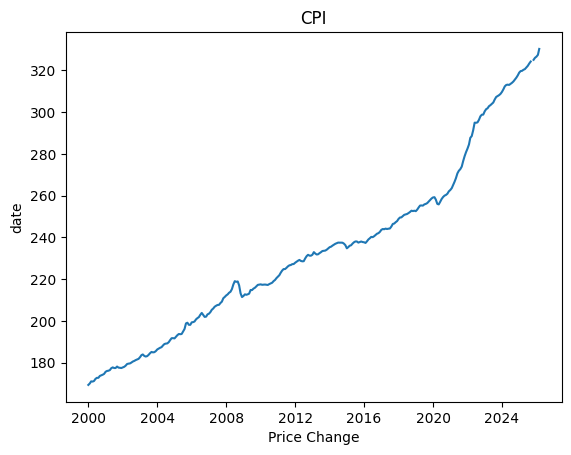

In [ ]:
plt.plot(inf['date'], inf['CPIAUCSL'])
plt.title("CPI")
plt.xlabel("Price Change")
plt.ylabel("date")
plt.show()

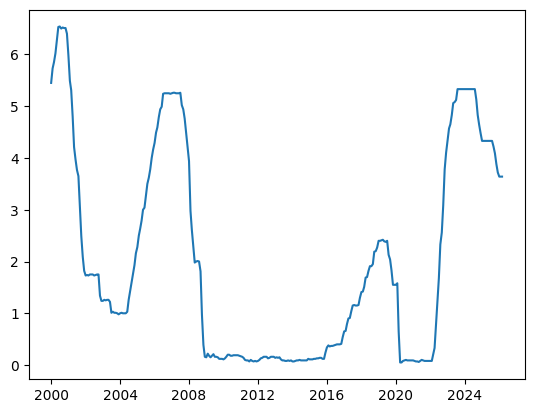

In [ ]:
plt.plot(intr['date'], intr['FEDFUNDS'])

The code above shows a simple graph of CPI and Interest rate in the time rage we are working with.

In [ ]:
start = "2000-01-01"
end = '2026-03-01'
tickers = {"Tech":"XLK","Financials": "XLF","Energy":"XLE", "Utilities":"XLU","S&P500":"^GSPC"}

This code creates a library of the sectors of the S&P 500, which will amke them easier to use. This code also sets the time frame we are using for all the data sets.

In [ ]:
prices = yf.download(list(tickers.values()), start=start, end=end)
prices = prices["Close"]
inverse_tickers_map = {v: k for k, v in tickers.items()}
prices = prices.rename(columns= inverse_tickers_map)
returns = prices.pct_change().dropna()

[*********************100%***********************]  5 of 5 completed


Renames symbols to assigned names in ticker dictionary above, and creates variables for prices and returns.

In [ ]:
import pandas_datareader.data as web
import datetime

Installing pandas "web scrapperish" used to pull CPI and interest rate data from FRED much easier than downloading files and selecting dates and frequency

In [ ]:
cpi = web.DataReader('CPIAUCSL', "fred", start, end)
rates = web.DataReader('FEDFUNDS', 'fred',start, end)
inflation = cpi.pct_change()
int_change = rates.diff()
df1 =pd.concat([inflation, int_change], axis =1)
df1.columns = ["inflation", "int_change"]
df1.head(20)
df1=df1.dropna()

/tmp/ipykernel_11663/798991388.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  inflation = cpi.pct_change()


The code pulls CPI data (CPIAUCSL) from FRED( Federal Reserve of St Louis) and interest rates (FEDFUNDS) using the assinged start and end times from the beginning. From there we set both to be the same frequency and combined the standarized datasets into one. We checked the data sets and for safety removed any missing values.

### part 2
In this section we compare the stock Market sectors to inflation and interest rate. We do this by running OLS Regressions and creating correlation maps. The goal of this section is to indentify which sectors have the highest correlation with inflation and interest rate.

From this point we did some basic linear regression, and analyzed the standard deviation of it. End goal of this section is to identify target sectors and create correlation maps

In [ ]:
data = returns.join(df1, how="inner")
vol = data.rolling(6).std()
high_vol = vol["inflation"] > vol["inflation"].quantile(.9)

In [ ]:
results ={}
for sector in ['Tech', 'Financials', 'Energy', 'Utilities']:
    X = data[['inflation', 'int_change']]
    X = sm.add_constant(X)
    y = data[sector]
    model = sm.OLS(y,X).fit()
    results[sector]=model.summary()
print(results['Tech'])
print(results['Financials'])
print(results['Energy'])
print(results['Utilities'])

                            OLS Regression Results                            
Dep. Variable:                   Tech   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     3.922
Date:                Thu, 14 May 2026   Prob (F-statistic):             0.0214
Time:                        19:22:03   Log-Likelihood:                 540.19
No. Observations:                 200   AIC:                            -1074.
Df Residuals:                     197   BIC:                            -1064.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.001      0.433      0.6

This creates a for loop to run a OLS regression on any of the sectors in the Library, with this we can find the coefficient, and the correlation values that stick out the most and continue research on those sectors.

## The following sectors stuck out:
Tech: adjusted R$^{2}$ : .029, coefficient of inflation : 1.1
Financials: adjusted R$^{2}$: 0.22, coefficient of inflation: 1.23
Energy: adjusted R$^{2}$: .101, coefficient of inflation : 2.03
Utilities: adjusted R$^{2}$: .067, coefficient of inlfation: 1.24

In [ ]:
correlation = data.corr()
fig = px.imshow(correlation, color_continuous_scale='RdBu_r', aspect = 'auto')
fig.update_traces(text = correlation.round(3).values, texttemplate='%{text}',
hovertemplate = "Correlation: %{z:.2f}<extra></extra>")
fig.update_layout(title = "Correlation matrix", title_x=.5)

fig.write_html("Correlation_Matrix.html", include_plotlyjs= "inline")
fig.show()

The graph above gives us a much easier to read insite of how every sector is correlated to Inflation and interest. The important columns are the two on the far right. From here we can identify which sectors have the highest correlation values. The list is Energy, Utilities, and Tech. Now that these sectors have been identified we can look into what inflation does to their returns and why they have the highest correlation.

For our new technique, we used a bubble plot to compare multiple variables at once. Unlike a regular line graph, this visualization shows correlation with inflation, average return, and volatility in one chart. This helps us compare sector performance and risk more clearly.

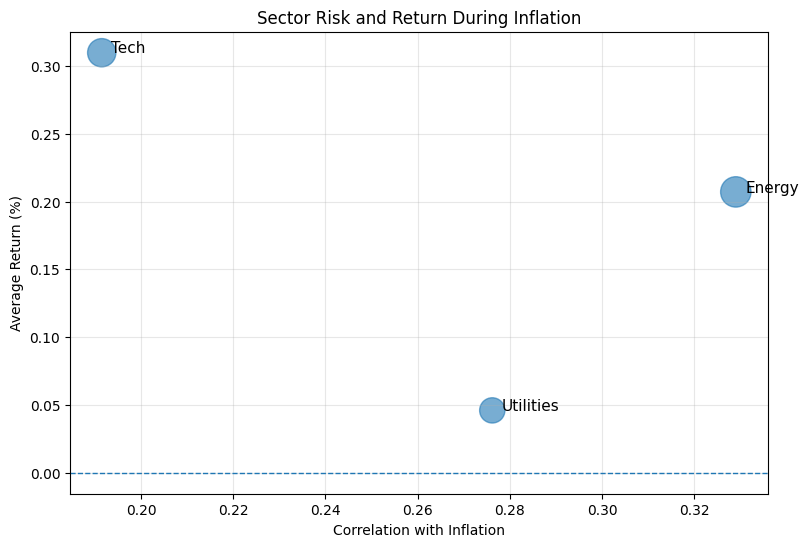

In [ ]:

sectors = ['Tech', 'Energy', 'Utilities']

corrs = [data[s].corr(data['inflation']) for s in sectors]
returns_avg = [data[s].mean() * 100 for s in sectors]
volatility = [data[s].std() for s in sectors]

sizes = [v * 25000 for v in volatility]

plt.figure(figsize=(9, 6))
plt.scatter(corrs, returns_avg, s=sizes, alpha=0.6)

for i, sector in enumerate(sectors):
    plt.text(corrs[i] + 0.002, returns_avg[i], sector, fontsize=11)

plt.axhline(0, linestyle='--', linewidth=1)
plt.xlabel("Correlation with Inflation")
plt.ylabel("Average Return (%)")
plt.title("Sector Risk and Return During Inflation")
plt.grid(True, alpha=0.3)
plt.show()

This bubble plot compares each sector across three dimensions: correlation with inflation, average return, and volatility. The x-axis shows how closely each sector moves with inflation, the y-axis shows average return, and the bubble size represents risk through volatility. This helps show that sectors do not respond to inflation in the same way, with Energy showing the strongest inflation relationship while Tech has the highest average return.


### Part 3



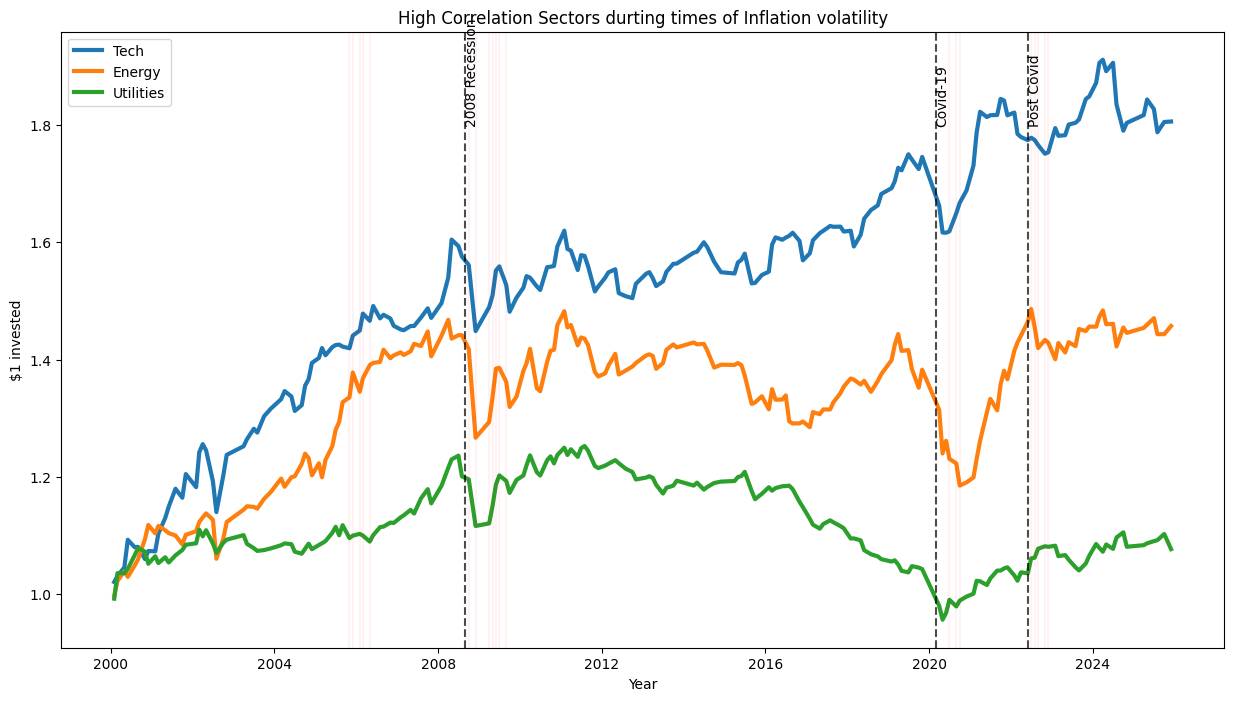

In [ ]:
df2 = (1+ data[['Tech','Energy','Utilities']]).cumprod()
plt.figure(figsize=(15,8))
for sector in df2.columns:
    plt.plot(df2.index, df2[sector], linewidth= 3, label= sector)

for high in high_vol[high_vol].index:
    plt.axvline(high, color= 'red', alpha = .05)


macroevents = {'2008 Recession': '2008-09-01', 'Covid-19': '2020-03-01', 'Post Covid':'2022-06-01'}

for label, macroevent_date in macroevents.items():
  macroevent_date = pd.to_datetime(macroevent_date)

  plt.axvline(macroevent_date, color='black', linestyle = '--', alpha = .7)

  plt.text(macroevent_date, plt.ylim()[1]* .92,label,rotation = 90, fontsize= 10)

plt.title("High Correlation Sectors durting times of Inflation volatility")
plt.xlabel("Year")
plt.ylabel("$1 invested")
plt.legend()
plt.show()


This graph shows how the 3 sectors we found moved over historical times of high inflation. The translucent red lines show the inflation at times of high volitility, aside from that the historic events are shown as well. This renforces our finding that the energy sector is the most impacted by inflation. Finally inflation is not the only determinant on how a stock will perform but understanding which sectors are most susceptible to high inflation is important when building a healthy and diverse portfolio.